In [1]:
suppressPackageStartupMessages({
    library(SeuratObject)

    library(org.Hs.eg.db)
    library(KEGGREST)
    library(Seurat)
    library(SeuratObject)
    library(AUCell)

# tools
    library(clusterProfiler) # read.gmt
    library(Matrix)
    library(magrittr) # %<>%
    library(dplyr)
    library(tidyverse)
    
    library(pheatmap)
    library(igraph)
    library(ggraph)
    library(patchwork)

    library(ggrepel)
    library(MAST)
    


})

source('FNC.r')
source('plotDesign.r')
sfile <- function(filename, folder="output") FNC(folder, filename, pfx="Figure5", sep="_", pfxDate = FALSE)

# Preparation

## KEGG Annotation

In [2]:
# Gain KEGG Pathway annotation

hsa_path_eg  <- keggLink("pathway", "hsa") %>% 
    tibble(pathway = ., eg = sub("hsa:", "", names(.)))

hsa_kegg_anno <- hsa_path_eg %>%
    mutate(
        symbol = mapIds(org.Hs.eg.db, eg, "SYMBOL", "ENTREZID"),
        ensembl = mapIds(org.Hs.eg.db, eg, "ENSEMBL", "ENTREZID")
    )

hsa_pathways <- keggList("pathway", "hsa") %>% 
    tibble(pathway = names(.), description = .)

hsa_pathways$parent <- hsa_pathways$grand <- NA
for(i in 1:nrow(hsa_pathways)){
    #message(path)
    tryCatch({
        KeggMeta <- keggGet(hsa_pathways$pathway[i])[[1]]$CLASS
        if(is.null(KeggMeta)) next
    },
    error = function(e){
        message(e)
        next
    })
    parents = as.vector(unlist(strsplit(KeggMeta,";")))
    hsa_pathways$parent[i] <-  parents[2]
    hsa_pathways$grand[i] <- parents[1]
}

hsa_kegg_anno$pathway_ <- str_split_i(hsa_kegg_anno$pathway,pattern = ":", i=2)
hsa_kegg_anno$parent <- hsa_pathways$parent[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]
hsa_kegg_anno$grand <- hsa_pathways$grand[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]
hsa_kegg_anno$description <- hsa_pathways$description[match(hsa_kegg_anno$pathway_, hsa_pathways$pathway)]

saveRDS(hsa_kegg_anno, "KEGG_annotation_gene_term.RDS")

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



## Load seurat

In [3]:
# load seuratObj coi
seu <- readRDS("output/1_annot_coi_seu.rds")
# load annotation
annotation <- readRDS("output/1_annot_coi_annotation.rds")

In [4]:
seu@meta.data$interactome_annotation = NA
seu@meta.data[names(annotation), "interactome_annotation"] <- annotation
seu@meta.data$samples <- seu@meta.data$orig.ident

In [5]:
table(seu@meta.data$interactome_annotation)


   aa-like CD8       CD4_TRM1    Hepatocytes Macrophages/DC 
         16063           1018          13307           7225 

In [6]:
seu_hep <- subset(seu, interactome_annotation == "Hepatocytes")

## Load TNF Pathway

In [7]:
# Load KEGG Annotation (in case, you re-run the script and already saved the KEGG_annotation_terms
hsa_kegg_anno <- readRDS("KEGG_annotation_gene_term.RDS")

In [8]:
KGTNF <- hsa_kegg_anno %>% 
        subset(pathway_ == "hsa04668") %>% select(columns = "symbol") %>% unlist %>% unname
AdhGenes <- hsa_kegg_anno %>% 
        subset(pathway_ == "hsa04514") %>% select(columns = "symbol") %>% unlist %>% unname

# AUCell and Hurdle

In [9]:
hurdleModel <- function(seuObj, geneSet, method = "AUC", showGenes = NULL, returnAUC = FALSE){
    # check input 
    if(!( typeof(seuObj) == "S4" && class(seuObj) == "Seurat")) 
        stop("seuObj must be a Seurat S4 Class")
    if(!(all(c("nFeature_RNA", "orig.ident") %in% colnames(seu_hep@meta.data)))) 
        stop("Seurat meta data must contain >>nFeature_RNA<< and >>orig.ident<<")
    if(!(is.vector(geneSet) && length(geneSet) > 0)) 
        stop("geneSet must be a vector with gene names and at least one gene needs to be passed")
    if(!(any(tolower(method) %in% c("auc", "modulescore")))) 
        stop("Please select a valid method: auc for AUCell and modulscore for Seurat AddModuleScore")
    

    mtx <- seuObj@assays$RNA@data
    cdr_ <- scale(seuObj$nFeature_RNA)
    org_ <- factor(seuObj$orig.ident)
    geneSets <- list(SOI = geneSet)

    if(tolower(method) == "modulescore"){
        seuObj <- AddModuleScore(seuObj, features = list(SOI = geneSet), name = "SOI", assay = "RNA")
        SOI_values <- seuObj$SOI1
        randG <- sample(rownames(mtx), size = length(geneSets[[1]])) 
        seuObj <- AddModuleScore(seuObj, features = list(randG = randG), name = "randG", assay = "RNA")

        auc_p <- wilcox.test(x=SOI_values , y= seuObj$randG1)$p.value
        stars <- ifelse(auc_p < 0.05, paste0(rep("*", -1*max(log10(auc_p), -4)), collapse = ""), "n.s.")
        print(paste0("Module score geneset vs random geneset -> sig. level: ", stars))
        

    }
    else if(tolower(method) == "auc"){
    # AUCell
        geneSets$randG <- sample(rownames(mtx), size = length(geneSets[[1]]))                                                                                    
        cells_rankings <- AUCell_buildRankings(mtx, plotStats=T)
        cells_AUC <- AUCell_calcAUC(geneSets, cells_rankings)
        cells_AUC_values <- cells_AUC@assays@data$AUC %>% t %>% as.data.frame
        SOI_values <- cells_AUC_values[, "SOI"]
        names(SOI_values) <- colnames(cells_AUC_values)

        auc_p <- wilcox.test(x=SOI_values, y= cells_AUC_values[, "randG"])$p.value
        stars <- ifelse(auc_p < 0.05, paste0(rep("*", -1*max(log10(auc_p), -4)), collapse = ""), "n.s.")
        print(paste0("AUCell geneset vs random geneset -> sig. level: ", stars))
    }
    else
       stop("You shouldnt reach that point! Check your method input!")
    
    # MAST Hurdle
    suppressMessages({
        scaRaw <- FromMatrix(exprsArray = mtx %>% as.matrix,  
                             cData = data.frame(
                                 SOI = SOI_values, 
                                 cdr = cdr_, 
                                 org = org_
                             ), 
                             fData = data.frame(rownames(mtx)))
    })
    if(!is.null(showGenes))
        showGenes %<>% .[. %in% rownames(mtx)]
        scaRaw <- scaRaw[showGenes,]
    suppressMessages({
        zlmCond <- zlm(~SOI + cdr + org, scaRaw)
        summaryCond <- summary(zlmCond, doLRT='SOI') 
        summaryCond$datatable %<>% mutate(fdr = p.adjust(`Pr(>Chisq)`, method="fdr"))
    })
    summaryDt <- summaryCond$datatable
    fcHurdle <- merge(summaryDt[contrast=='SOI' & component=='H',.(primerid, fdr, z)], #hurdle P values
                      summaryDt[contrast=='SOI' & component=='logFC', .(primerid, coef, ci.hi, ci.lo, z)], 
                  by='primerid')
    if(returnAUC && tolower(method) == "auc")
        return(list(hurdle=fcHurdle, AUC = cells_AUC))
    else{
        if(returnAUC) message("Please select method auc to return a AUCell object")
        return(fcHurdle)
    }


}

Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



  min    1%    5%   10%   50%  100% 
  401   608  1266  1701  3239 12242 


Genes in the gene sets NOT available in the dataset: 
	SOI: 	1 (1% of 116)



[1] "AUCell geneset vs random geneset -> sig. level: ****"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.6 GiB”


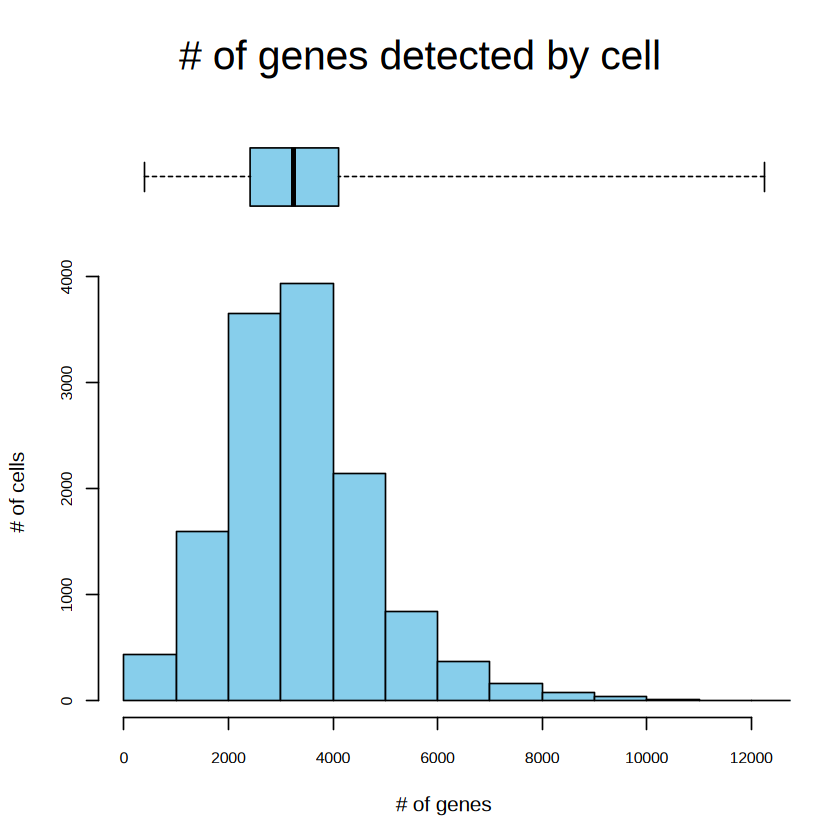

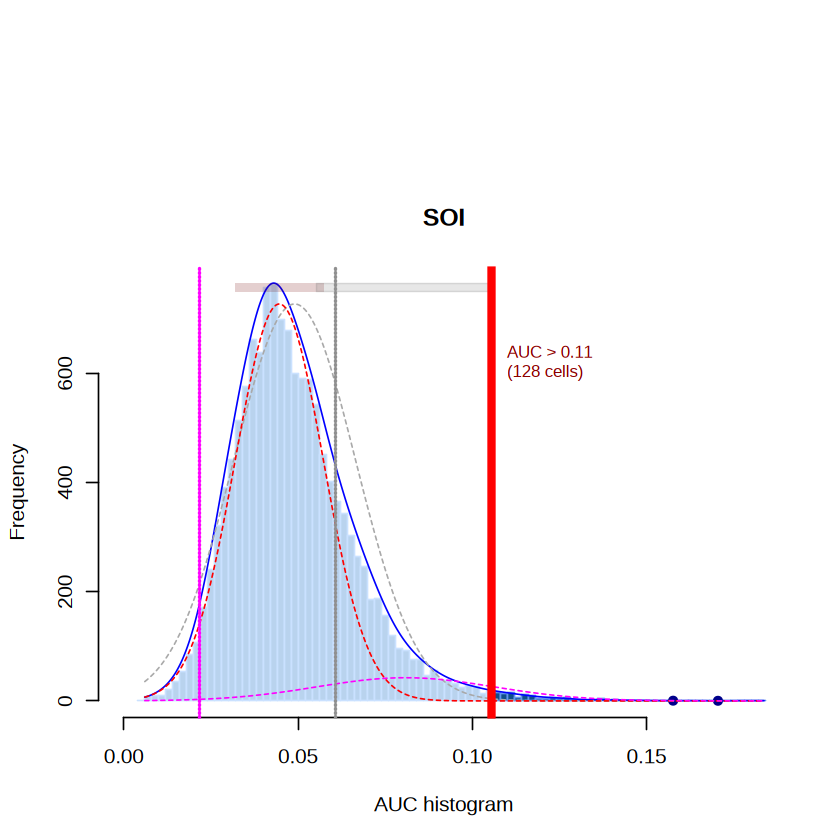

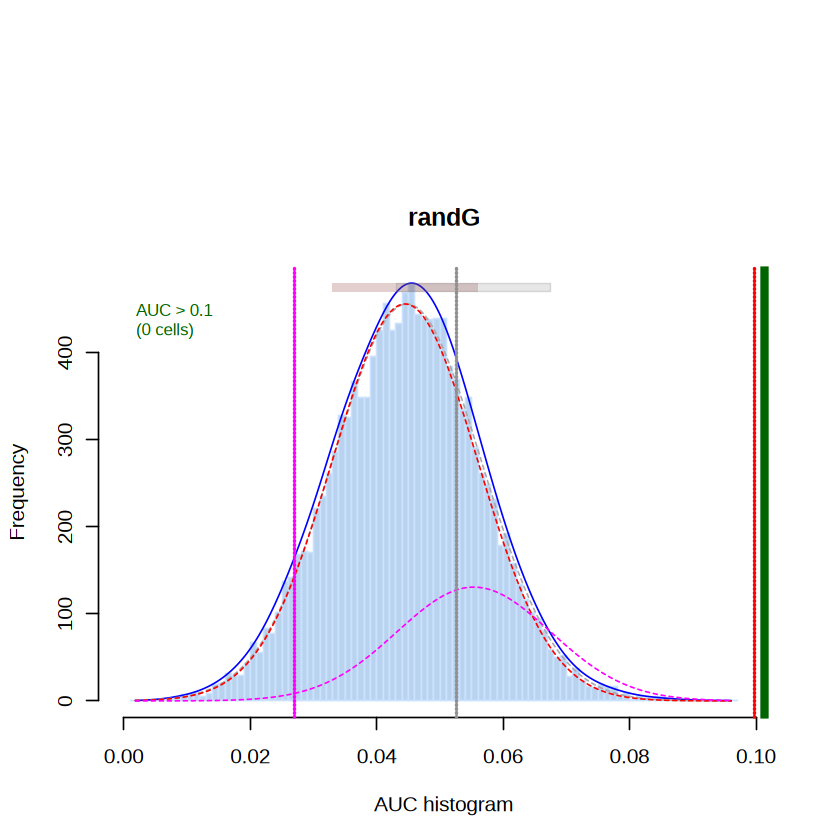

In [10]:
# Remove adhesion molecules
geneSets <- KGTNF[!(KGTNF %in% AdhGenes)]
# calculate hurdle values
hurdle_df <- hurdleModel(seu_hep, geneSets, showGenes = AdhGenes, returnAUC = TRUE)

# save AUC output 
#dev.copy(pdf, sfile("AUC_GeneDistribution.pdf"), width=5, height=5)
#dev.off()

#pdf(sfile("AUCell_automatic_cutoff.pdf"), width=5, height=5)
    cells_assignment <- AUCell_exploreThresholds(hurdle_df$AUC, plotHist=TRUE, assign=TRUE) 
#dev.off()

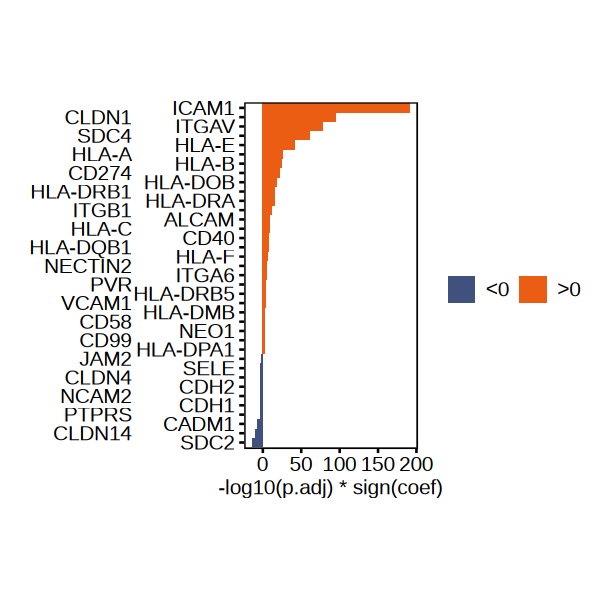

In [11]:
options(repr.plot.width=5, repr.plot.height=5)

fcHurdle <- hurdle_df$hurdle
p <- ggplot(subset(fcHurdle, fdr <= 0.01), 
       aes(x=-log10(fdr)*sign(coef), y=reorder(primerid, -log10(fdr)*sign(coef), decreasing = FALSE), 
           fill=ifelse(coef > 0, ">0", "<0"))) +
    geom_bar(stat="Identity") + 
    scale_fill_manual(values = c(">0"=colors$palette$DarkBlue_Red$basefunc(4)[4], 
                  "<0"=colors$palette$DarkBlue_Red$basefunc(4)[1])) +
    scale_y_discrete(guide = guide_axis(n.dodge = 2)) +
    labs(y="", x="-log10(p.adj) * sign(coef)", fill="") +
    theme_paper(aspect.ratio = 2/1) + guides(fill=guide_legend(nrow=1, byrow = TRUE))
p


ggsave(sfile("Hurdle_MAST_lRT.pdf"), width = 15, height=5)
write.csv(fcHurdle, sfile("Hurdle_MAST_lRT.csv"))
saveRDS(p, sfile("img_Hurdle_MAST_lR.RDS"))

In [ ]:
library(ggbeeswarm)
ggdf = rbind(data.frame(AUC = hurdle_df$AUC@assays@data$AUC["SOI",], feature = "Hepatocytes"))
ggdf$threshold = ifelse(ggdf$AUC > cells_assignment$SOI$aucThr$selected, "above", "below")

p <- ggplot(ggdf, aes(y=AUC, x=feature, color=threshold)) +  
        geom_quasirandom(method = "pseudorandom") + 
        geom_hline(yintercept = cells_assignment$SOI$aucThr$selected, linetype ="dotted") + 
        stat_summary(fun.y=median, geom='point', pch=21, size=3, color="black", fill="white") + 
        scale_color_manual(values = colors$ast_alt %>% unname) + 
        xlab("") + ylab("AUC score \n (KEGG:hsa04668 \\ KEGG:hsa04514)") + 
        theme_paper(aspect.ratio = 2/1)

p 

ggsave(sfile("TNF_Threshold_Violin.pdf"), width = 3, height=6)
write.csv(fcHurdle, sfile("TNF_Threshold_Violin.csv"))
saveRDS(p, sfile("TNF_Threshold_Violin.RDS"))

DefaultAssay(seu_hep) <- "RNA"
markers <- FindMarkers(seu_hep, ident.1 = cells_assignment$SOI$assignment)
mm <- markers %>% rownames_to_column("genes") %>% subset(genes %in% AdhGenes)

p <- ggplot(mm, aes(x=avg_log2FC, y=-log10(p_val_adj), color=ifelse(p_val_adj < 0.05, "sig", "not"))) + 
        geom_point() +
        geom_vline(xintercept = 0, linetype="dotted") + 
        geom_text_repel(data= subset(mm, p_val_adj < 0.05), aes(label=genes), color="black") + 
        scale_color_manual(values = rev(colors$ast_alt %>% unname)) + 
        labs(x="average log2-transformed fold change", y="negative log10-transformed adjusted p-values") + 
        theme_paper() + theme(legend.position = "none")

p 

ggsave(sfile("TNF_Threshold_DE.pdf"), width = 5, height=5)
write.csv(fcHurdle, sfile("TNF_Threshold_DE.csv"))
saveRDS(p, sfile("TNF_Threshold_DE.RDS"))

Warning message:
“The `fun.y` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun` argument instead.”
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session



In [ ]:
hepatocytes_annotation <- read.csv("Interactom_annotation/Interactom_hepatocytes_annotation.csv")
hepatocytes_annotation <- subset(hepatocytes_annotation, X %in% colnames(seu_hep))
seu_hep@meta.data$annot = NA
seu_hep@meta.data[hepatocytes_annotation$X,"annot"] <- hepatocytes_annotation$annotation

seu_hep@meta.data <- cbind(seu_hep@meta.data, hurdle_df$AUC@assays@data$AUC %>% t %>% as.data.frame)
#DimPlot(subset(seu_hep, cells = colnames(seu_hep)[is.na(seu_hep@meta.data$annot)]) , group.by="annot" ) + theme_paper()
FeaturePlot(seu_hep, "SOI", order = T) + labs(title="TNF Score") + theme_paper()


p <- VlnPlot(seu_hep, features = "SOI", pt.size = 0, group.by ="annot") + 
stat_summary(fun.y=median, geom='point', pch=21, size=3, color="black", fill="white")  + labs(x="", y="") + 
theme_paper() + theme(axis.text.x = element_text(angle=90, hjust=1, vjust=0.5)) + NoLegend()

p

ggsave(sfile("TNF_Violin_Annotation.pdf"), width = 6, height=6)
write.csv(fcHurdle, sfile("TNF_Violin_Annotation.csv"))
saveRDS(p, sfile("TNF_Violin_Annotation.RDS"))

# Session

In [ ]:
sessionInfo()